# **Curve Fitting**

# Function Definition and Testing

**Importing Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style
import matplotlib as mpl

#Seting the default figure size
mpl.rcParams['figure.dpi']=210 # number of dots per inch


## Defining the Function

The polynomials which will be used has the form:

$$y(x) = \sum_i \theta_i x^i $$

where $\theta_i$ represents the coefficient of the $i^{th}$ order of the polynomial and $x$ is the argument of the function.

A Gaussian with a mean $\mu$ and standard deviation $\sigma$, is given by

$$P(x; \mu, \sigma) = \frac{1}{\sigma \sqrt{2 \pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2} $$

In this notebook, a mean of $\mu=0$ and standard deviation $\sigma=0.5$ will be applied. In addition, the noise for the polynomial will be values randomly picked from the Gaussian.

In [ ]:
def polyModel(x, theta):
    """
    Compute polynomial values for given x values and coefficients.
    y(x) = Σ_i θ_i x ^ i

    Arguments:
        x: Input x values
        theta: Polynomial coefficients where theta[i] is coefficient for x^i

    Returns:
        Computed y values in an array
    """
    y = 0 #y is initialized to 0

    for i, value in enumerate(theta): # Iterating over index and value
        y += value * x ** i

    return y

def polyModelWithNoise(x,theta,sigma):
    """
    Compute polynomial values with added Gaussian noise.
    y(x) = Σ_i θ_i x ^ i

    Args:
        x: Input x values
        theta : Polynomial coefficients where theta[i] is coefficient for x^i
        sigma : Standard deviation of the noise

    Returns:
        Computed y values with noise
    """
    base_values = polyModel(x, theta) #Calls the previously defined polyModel function to compute the polynomial values without noise
    noise = np.random.normal(0, sigma, size=len(x)) #adds randomness by generating Gaussian noise to mimic real-world variability, where mean = 0 (centered around zero, so it doesn't bias the result)
    return base_values + noise



Now, we'll plot the polynomial \(1 + 3x\) over the domain \(0 < x < 1\). To achieve this, we'll use our polynomial function and create two arrays: $\theta$ = `[1,3]` and \(x\), consisting of 100 evenly spaced values between 0 and 1. We need two arrays (𝑥 and θ) because: x provides the inputs for evaluating the polynomial over a smooth range. θ specifies the parameters that define the polynomial's shape and behavior.

Additionally, we'll plot the polynomial with Gaussian noise added to it.

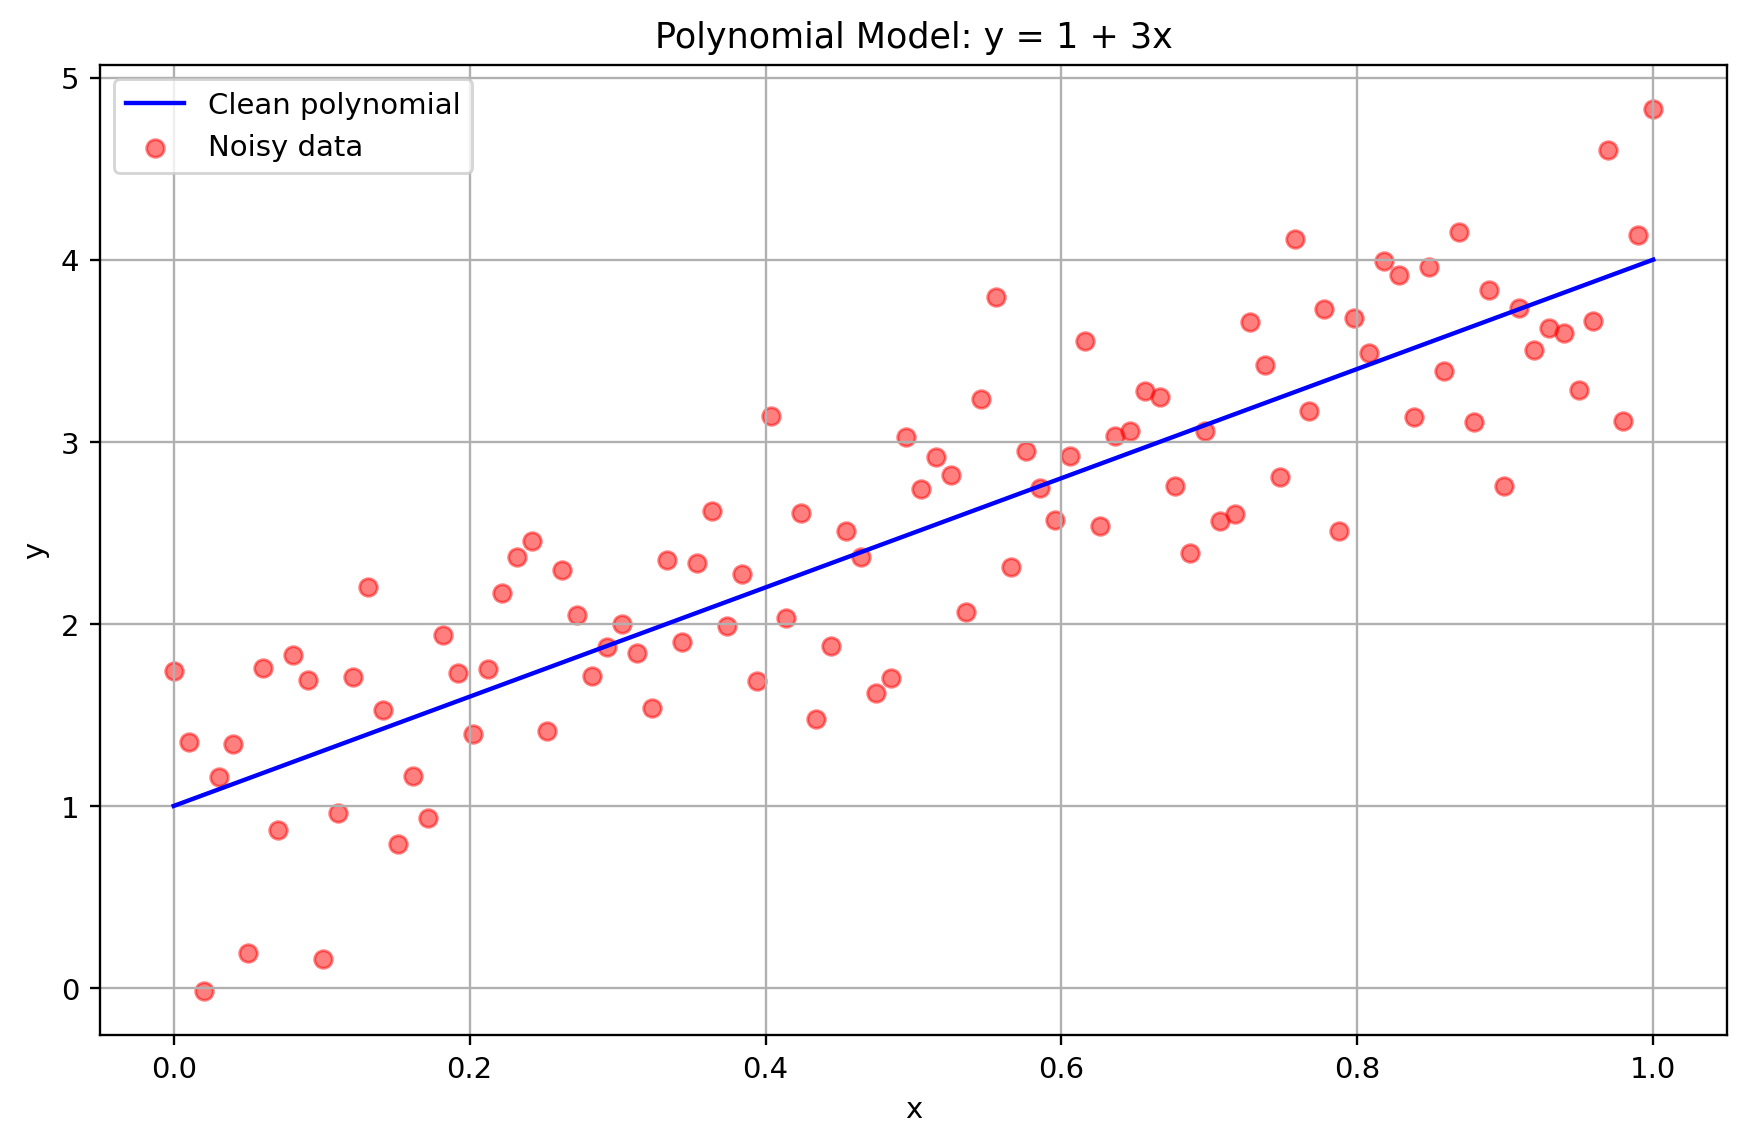

In [ ]:
# Generate x values
x = np.linspace(0, 1, 100)

# Set parameters
theta = np.array([1, 3])  # y = 1 + 3x
sigma = 0.5

# Compute values
y_clean = polyModel(x, theta)
y_noisy = polyModelWithNoise(x, theta, sigma)

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(x, y_clean, 'b-', label='Clean polynomial')
plt.scatter(x, y_noisy, c='r', alpha=0.5, label='Noisy data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Model: y = 1 + 3x')
plt.legend()
plt.grid(True)
plt.show()

**Gradient Descent Method**

At its core, gradient descent answers this question: *How can we adjust the parameters of a model to minimize the error between the predicted and true values?*

Stochastic Gradient Descent computes the gradient using a small batch of random data points at a time.It is fast updates and can handle large datasets. Another pro about this technique is that it introduces randomness, which helps escape local minima. However, updates fluctuate, which can make it harder to converge precisely.

1. The gradient

The gradient is a vector of partial derivatives of the loss function with respect to each model parameter. It points in the direction of the steepest increase in the function's value. The larger the gradient, the larger the change in the parameter needed to reduce the loss.


2. The update rule for each parameter
Gradient descent updates the parameters θ in the direction opposite to the gradient (because we want to minimize the loss, not increase it). The update rule for each parameter is:
$$ \theta_{i+1} := \theta_i - \eta_i \left< \Delta y\right> \frac{\partial y}{\partial \theta} $$
where $\eta_i$ is the learning rate, which controls the step size.

## Defining the Functions

To find the next values of $\theta$, we need the derivative of our polynomial $y(x)$ with respect to $\theta$. As mentioned above, the equation of the polynomial is given by

$$ y(x) = \sum_i \theta_i x^{i} $$

Differentiating this with respect to $\theta_i$:

$$ \frac{\partial y}{\partial \theta_i} = x^{i}. $$

A polyGradient function that will give the gradient above will be created. It will take an array of $𝑥$-values and $\theta$ and iterates over $\theta$ and calculates the contribution of each 𝜃  term for a given x-value, storing these contributions in the gradient matrix.



In [ ]:
def polyGradient(x, theta):
    """
    Compute the gradient of the polynomial with respect to theta coefficients.

    Arguments:
        x: 1D Numpy Array
        theta: D Numpy Array of coefficients
    Returns:
       Gradient matrix (shape: m x n).
    """


    # Initialise the gradient array with shape (m, n)
    gradient = np.zeros(((len(theta),len(x))))

    # Compute the gradient for each theta_i
    for i in range((len(theta))):
        gradient[i] = x**i  # Fill the i-th row with x^i values

    return gradient




## Stochastic Gradient Descent

For stochastic gradient descent, we take a small batch of values in each iteration (in this case, we will take 10 values between 0 and 1).
Our true parameter is `[1,4]` and the initial parameter is `[−1,0.5]`.

Equation for mean squared error:

$$ \textrm{MSE} = \frac{1}{N} \sum_i^N \left( y(x_i;\theta) - \tilde{y} \right)^2 $$
where $\tilde{y}$ is the true distribution that we are trying to attain with $y(x_i;\theta)$.

We will calculate the MSE at each iteration and plot it afterward to observe whether it converges.



In [ ]:
# Initialize parameters
true_theta = np.array([1, 4])  # True parameters
current_theta = np.array([-1, 0.5])  # Initial guess
sigma = 0.5  # Noise level
learning_rate = 0.5
n_iterations = 100
sample_size = 10

# Create arrays to store history
mse_history = np.zeros(n_iterations)  # Array for MSE history

# Gradient descent loop
for i in range(n_iterations):
    # 1. Generate random x values
    x_sample = np.random.uniform(0, 1, sample_size)

    # 2. Generate noisy y data with true parameters
    y_data = polyModelWithNoise(x_sample, true_theta, sigma)

    # 3. Generate y model values with current parameters
    y_model = polyModel(x_sample, current_theta)

    # 4. Calculate error and MSE
    error = y_model - y_data
    mse_history[i] = np.mean(error**2)

    # 5. Calculate gradient and update theta
    current_theta -= learning_rate*np.average(error*polyGradient(x_sample, current_theta),axis=1)



Plotting MSE for 1st order Polynomial

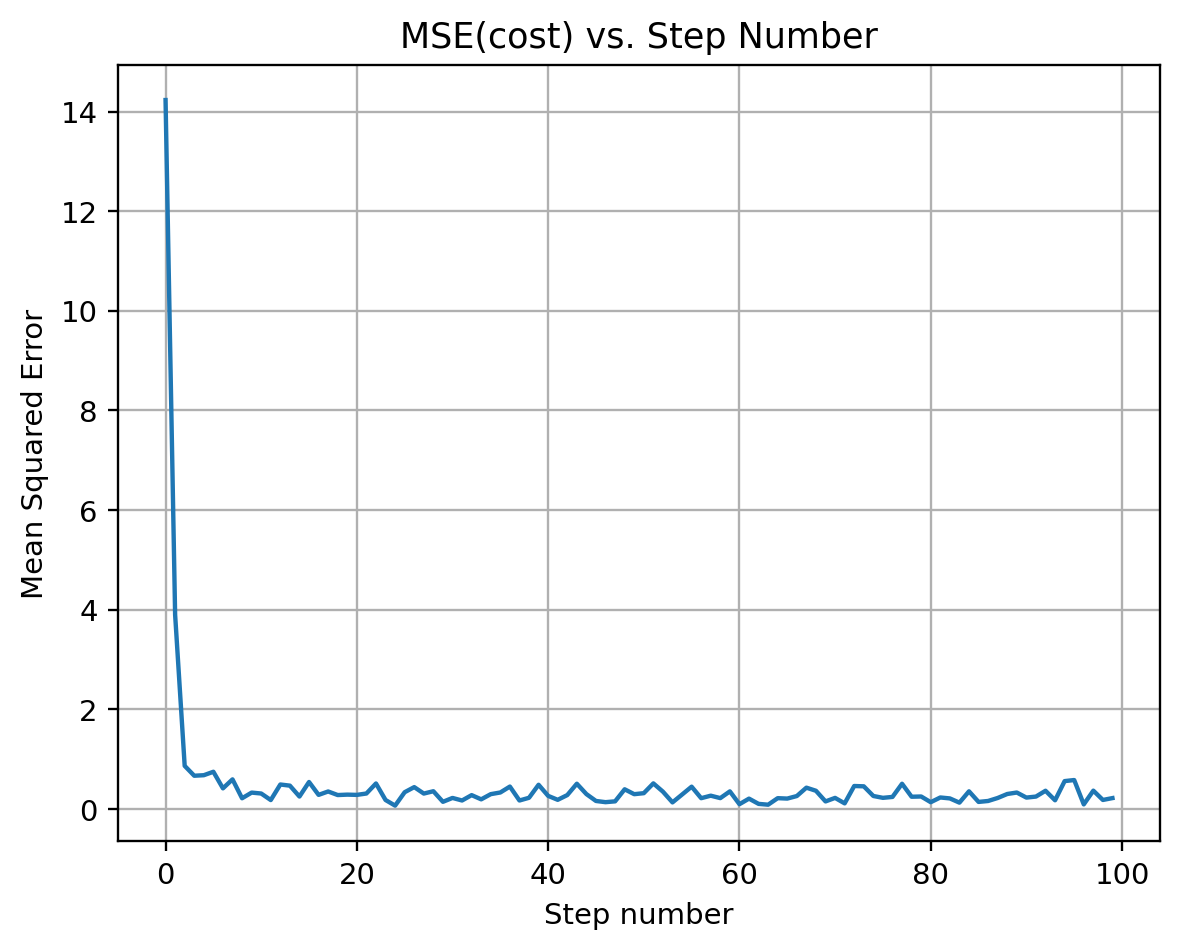

In [ ]:
# Plot results
fig, ax = plt.subplots()

# Plot MSE over iterations
ax.plot(mse_history)
ax.set_xlabel('Step number')
ax.set_ylabel('Mean Squared Error')
ax.set_title('MSE(cost) vs. Step Number')
ax.grid(True)


# Fitting a third order polynomial
We achieved satisfactory convergence of the MSE with our first-order polynomial. Next, we plan to fit a third-order polynomial with the true parameter vector θ=[1,4,3,2]. To explore its performance, we will fit first-order, third-order, and seventh-order models, all of which start with θ initialized to zero.

Using stochastic gradient descent in the interval 0<x<1, we will iteratively update the values of θ. Finally, we will plot the resulting MSEs to visualize how well each model converges.

In [ ]:
# Initialize 2D arrays to store theta arrays for different model orders
theta = [np.zeros(2), np.zeros(4), np.zeros(8)]  # 1st, 3rd, and 7th-order models
thetaTrue = [1, 4, 3, 2]  # True coefficients for the third-order polynomial

# Initialize a 2D array to store Mean Squared Error (MSE) values during iterations
MSE = np.zeros((len(theta), n_iterations))  # Rows correspond to model orders, columns to iterations

# Create a dictionary to map model indices to their corresponding labels
orders = {0: '1st', 1: '3rd', 2: '7th'}

# Plot polynomial fits for each order (initial state, before training)
for order in orders:
    ax.plot(x, polyModel(x, theta[order]), label=f"{orders[order]} order fit")

# Perform gradient descent for each model order
for i in range(len(theta)):
    for j in range(n_iterations):
        # Generate a random sample of input values within the range [0, 1]
        x = np.random.uniform(0, 1, 10)

        # Generate noisy data based on the true polynomial
        y_data = polyModelWithNoise(x, thetaTrue, sigma)

        # Compute the model's output using the current theta values
        y_model = polyModel(x, theta[i])

        # Calculate the error between the model's output and the noisy data
        error = y_model - y_data

        # Update the model's parameters using stochastic gradient descent
        theta[i] -= learning_rate * np.average(error * polyGradient(x, theta[i]), axis=1)

        # Compute and store the mean squared error for the current iteration
        MSE[i][j] = np.mean(error**2)


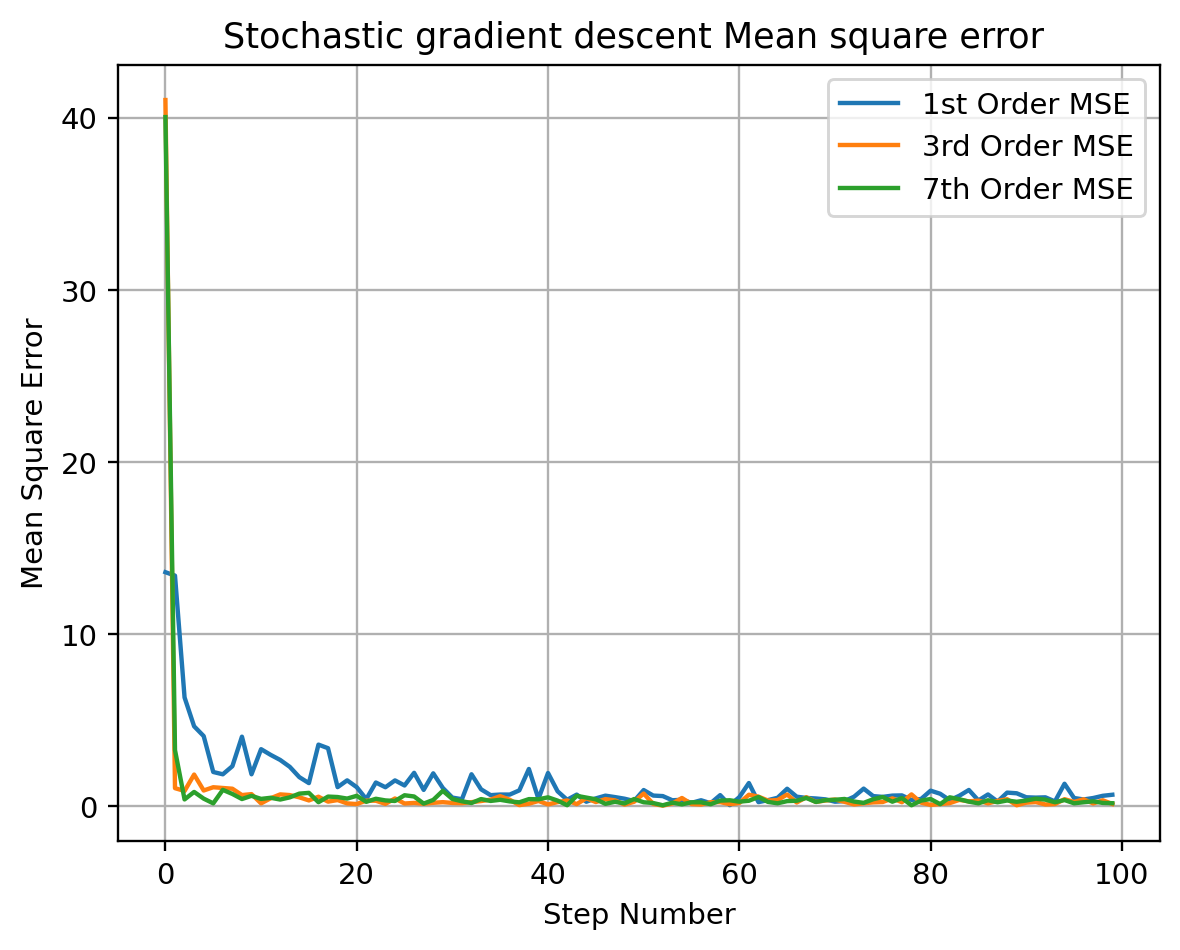

In [ ]:
fig, ax = plt.subplots()
ax.plot(MSE[0],label=r"1st Order MSE")
ax.plot(MSE[1],label=r"3rd Order MSE")
ax.plot(MSE[2],label=r"7th Order MSE")
ax.set_xlabel("Step Number")
ax.set_ylabel("Mean Square Error")
ax.set_title("Stochastic gradient descent Mean square error ")
ax.grid()
ax.legend()

**Analysis:**

The first-order polynomial exhibits the greatest instability—much more so than the third- and seventh-order models. Among these, the third-order polynomial appears the most stable, followed closely by the seventh-order polynomial. Overall, the third- and seventh-order polynomials demonstrate the best fit for the 0<x<1 range.

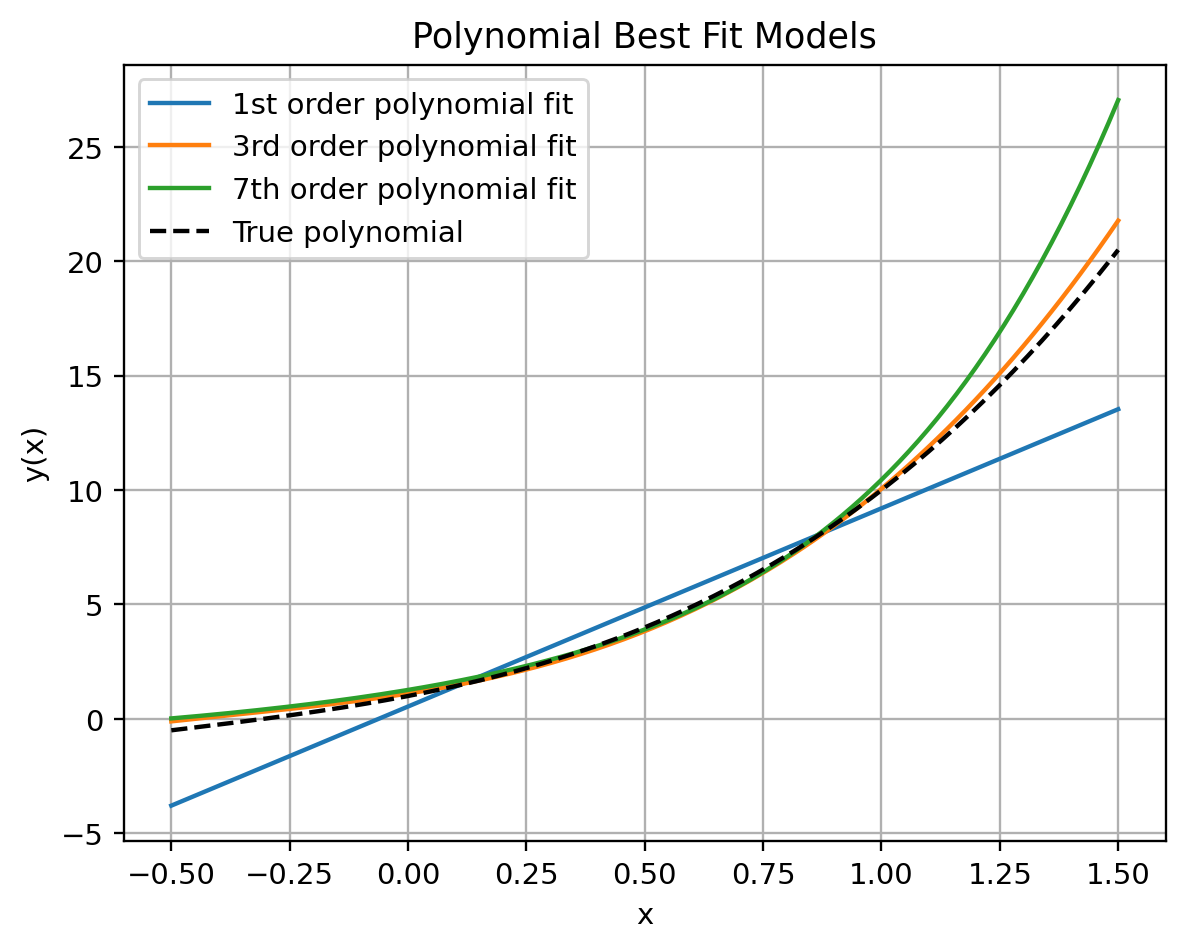

In [ ]:
# Generate an extended range for x from -0.5 to 1.5
x = np.linspace(-0.5, 1.5, 200)
fig, ax = plt.subplots()

# Dictionary to map each index to its corresponding polynomial order label
orders = {0: '1st', 1: '3rd', 2: '7th'}

# Plot the polynomial fit for each model order
for order in orders:
    ax.plot(x, polyModel(x, theta[order]), label=f"{orders[order]} order polynomial fit")

# Overlay the true polynomial (dashed black line)
ax.plot(x, polyModel(x, thetaTrue), '--', color='black', label=r"True polynomial")

ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.set_title("Polynomial Best Fit Models")
ax.grid(True)
ax.legend()


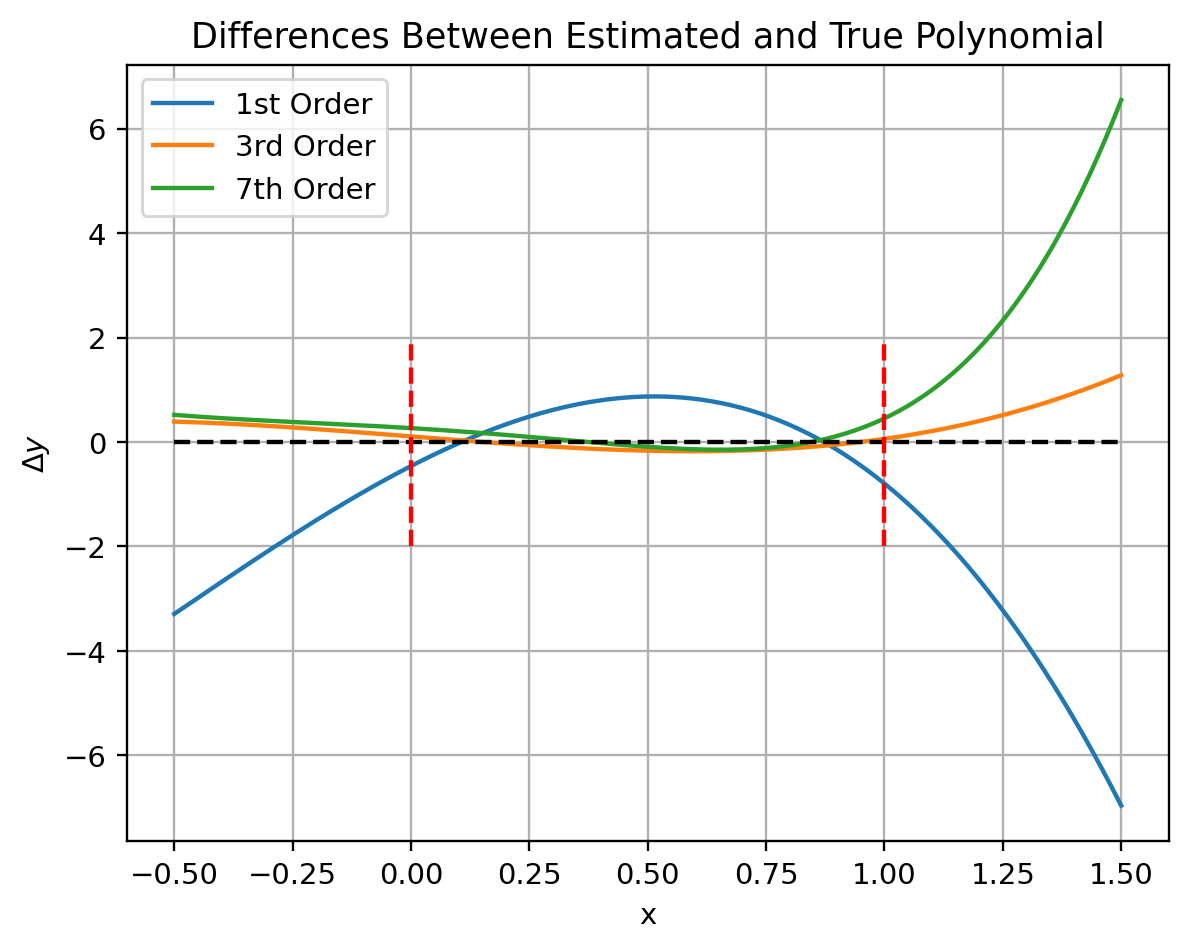

In [ ]:
fig, ax = plt.subplots()

# Plotting the difference between the true polynomial and the estimated polynomial for each model order
for order in orders:
    delta_y = polyModel(x, theta[order]) - polyModel(x, thetaTrue)
    ax.plot(x, delta_y, label=f"{orders[order]} Order")

# Add a horizontal reference line at zero
ax.plot(x, np.zeros(len(x)), '--', color='black')

# Mark the boundaries of the training region
y_min = -2
y_max = 2
ax.plot([0, 0], [y_min, y_max], linestyle='--', color='r')
ax.plot([1, 1], [y_min, y_max], linestyle='--', color='r')

ax.set_xlabel("x")
ax.set_ylabel("$\Delta y$")
ax.set_title("Differences Between Estimated and True Polynomial")
ax.grid(True)
ax.legend()


**Analysis of the results:**

*Training Error (MSE):*

When examining this plot, it’s clear how each polynomial model compares to the true polynomial within and beyond the training region. Inside the interval 0<x<1 (marked by the red dashed lines), the third-order fit shows the smallest deviation from the true polynomial, suggesting it is the most stable. The seventh-order fit also remains fairly close to the true function within that region, though it appears to grow slightly larger errors than the third-order model as x moves away from the center of the interval.

Beyond the trained range, all fits begin to deviate more significantly. The first-order fit in particular diverges more dramatically, demonstrating its limited flexibility. Overall, these error curves highlight that while both the third- and seventh-order polynomials do a satisfactory job in the training range, the third-order polynomial provides the most consistent approximation across 0<x<1.

*Generalization to Extended Range (-0.5 to 1.5):*

The linear model (1st order) provides poor fit but stable extrapolation
The 3rd order model gives the best overall performance, matching the true function both within and outside the training range
The 7th order model shows significant instability outside the training range (0 to 1), demonstrating classic overfitting behavior. The 3rd order polynomial achieves the best balance between fitting the training data and generalizing to new x values

The 7th order polynomial, while fitting the training data well, fails to generalize outside the training range
This is a clear example of the bias-variance tradeoff in machine learning

# Final Comments
The notebook runs smoothly and efficiently, with the computationally intensive sections—such as gradient descent and plotting—executing quickly. The gradient descent algorithm demonstrates reliable convergence, with each polynomial order adapting well to the dataset. The stochastic gradient descent approach is particularly effective in this context due to its reduced computational load per iteration, making it ideal for larger-scale problems. The visualizations effectively capture the differences in stability and accuracy between the polynomial fits, with the third-order model clearly emerging as the most balanced and accurate in the trained region (\(0 < x < 1\)). Beyond this range, the divergence of the higher-order models highlights the challenges of overfitting and extrapolation.

This implementation also showcases the flexibility of the approach, allowing for easy scaling to larger datasets or experimentation with alternative configurations. When working with \(n\) data points, traditional gradient descent calculates the gradient using all \(n\) points in each iteration, resulting in a time complexity of $(O(n))$ per step. This means that as the dataset grows, the computation required for each update increases linearly. In contrast, Stochastic Gradient Descent (SGD) updates the parameters using a single randomly chosen data point (or a fixed-size batch), which reduces the time complexity to $(O(1))$ per step. Here, $(O(1))$ implies that the time required for each update remains constant, regardless of the size of the dataset. While these updates might not directly target the steepest descent at every step, the randomness allows SGD to explore the parameter space more efficiently and often leads to convergence over multiple iterations. This efficiency makes SGD particularly valuable for large-scale datasets, where traditional gradient descent becomes computationally infeasible.

